In [94]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

from wiener_loss import WienerLoss, MSWienerLoss, PatchWienerLoss
from utils import set_seed

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(), 
    # transforms.Grayscale(num_output_channels=1)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

set_seed(42)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 8.55MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 220kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 2.68MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 1.76MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [103]:
x = next(iter(train_loader))[0]

filter_dim = len(x.shape) - 2
dims = tuple(range(2, 2 + filter_dim ))

Fx = torch.abs(torch.fft.fftshift(torch.fft.fft2(x, dim=dims)))
Fx = Fx * Fx

In [104]:
print(Fx.min(), Fx.max())

tensor(1860.8029) tensor(1.9784e+10)


<Figure size 1200x600 with 0 Axes>

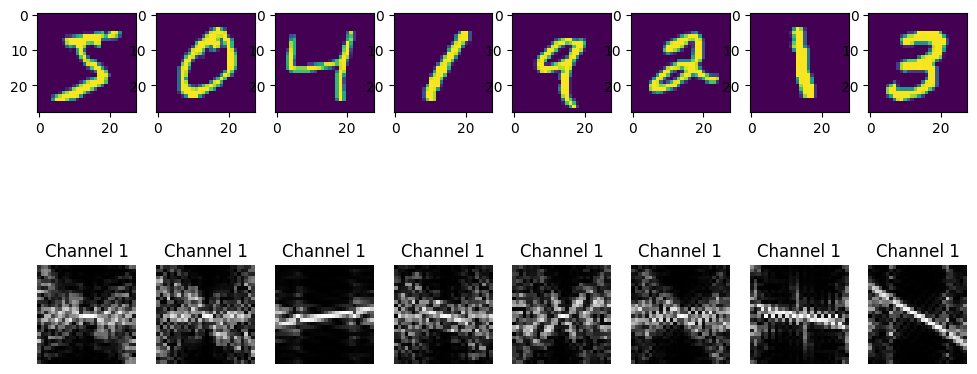

In [106]:
def rms(x):
    return torch.sqrt(torch.mean(x * x, dim=0))

nb, nc = x.shape[:2]

plt.figure(figsize=(12, 6)) 
fig, axs = plt.subplots(nrows=nc+1, ncols=nb, figsize=(12, 6))

for i in range(nb):
    axs[0][i].imshow(x[i].numpy().transpose(1, 2, 0))
    for j in range(nc):
        Fx_ = Fx[i, j]/ rms(Fx[i, j])
        axs[j+1][i].imshow(np.log1p(Fx_.numpy()), cmap='gray')
        axs[j+1][i].set_title(f'Channel {j+1}')
        axs[j+1][i].axis('off')

plt.show()


/var/folders/fq/ynhnpw_j05x2l8ypw293s7xw0000gp/T/ipykernel_96576/2832191395.py:18: RuntimeWarning: invalid value encountered in log1p
  axs[j+1][i].imshow(np.log1p(dx_), cmap='seismic', vmin=-3, vmax=3)


<Figure size 1200x600 with 0 Axes>

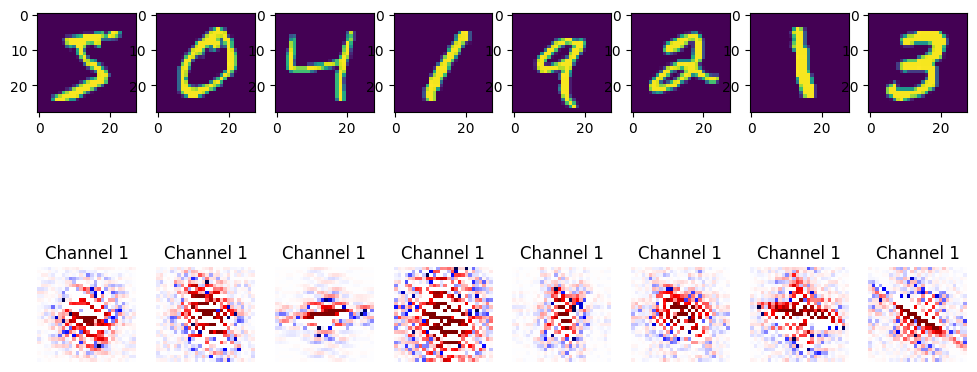

/var/folders/fq/ynhnpw_j05x2l8ypw293s7xw0000gp/T/ipykernel_96576/2832191395.py:30: RuntimeWarning: invalid value encountered in log1p
  axs[j+1][i].imshow(np.log1p(dy_), cmap='seismic', vmin=-3, vmax=3)


<Figure size 1200x600 with 0 Axes>

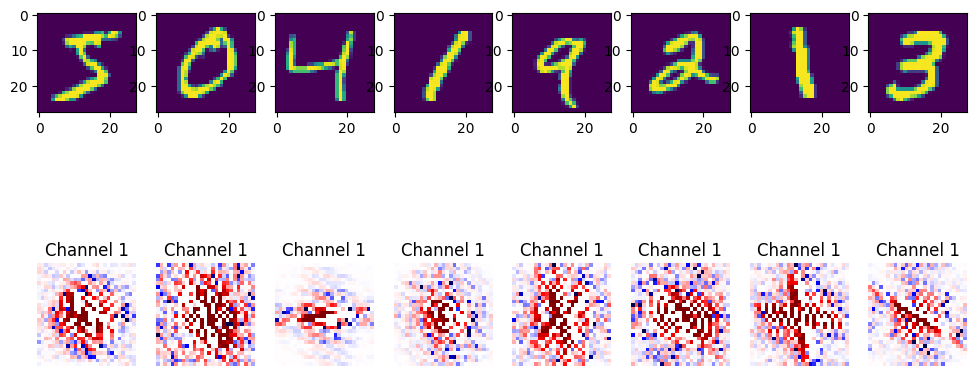

In [107]:
nb, nc = x.shape[:2]

def dx(x):
    return x[1:] - x[:-1]

def dy(x):
    return x[:, 1:] - x[:, :-1]



plt.figure(figsize=(12, 6)) 
fig, axs = plt.subplots(nrows=nc+1, ncols=nb, figsize=(12, 6))
for i in range(nb):
    axs[0][i].imshow(x[i].numpy().transpose(1, 2, 0))
    for j in range(nc):
        dx_ = dx(Fx[i, j].numpy())
        dx_ = dx_ / dx_.sum()
        axs[j+1][i].imshow(np.log1p(dx_), cmap='seismic', vmin=-3, vmax=3)
        axs[j+1][i].set_title(f'Channel {j+1}')
        axs[j+1][i].axis('off')
plt.show()

plt.figure(figsize=(12, 6)) 
fig, axs = plt.subplots(nrows=nc+1, ncols=nb, figsize=(12, 6))
for i in range(nb):
    axs[0][i].imshow(x[i].numpy().transpose(1, 2, 0))
    for j in range(nc):
        dy_ = dy(Fx[i, j].numpy())
        dy_ = dy_ / dy_.sum()
        axs[j+1][i].imshow(np.log1p(dy_), cmap='seismic', vmin=-3, vmax=3)
        axs[j+1][i].set_title(f'Channel {j+1}')
        axs[j+1][i].axis('off')
plt.show()


torch.Size([6272, 1, 1, 1])
tensor(0.) tensor(3.3133) tensor(0.3545) tensor(0.9351)
torch.Size([5832, 1, 2, 2])
tensor(0.) tensor(9.8249) tensor(0.3079) tensor(0.9506)
torch.Size([1352, 1, 4, 4])
tensor(0.) tensor(11.4309) tensor(0.4006) tensor(0.9162)
torch.Size([288, 1, 8, 8])
tensor(0.) tensor(8.4658) tensor(0.5405) tensor(0.8407)
torch.Size([32, 1, 16, 16])
tensor(1.2761e-14) tensor(4.7169) tensor(0.6691) tensor(0.7477)
torch.Size([8, 1, 28, 28])
tensor(0.0001) tensor(2.8148) tensor(0.7154) tensor(0.7321)


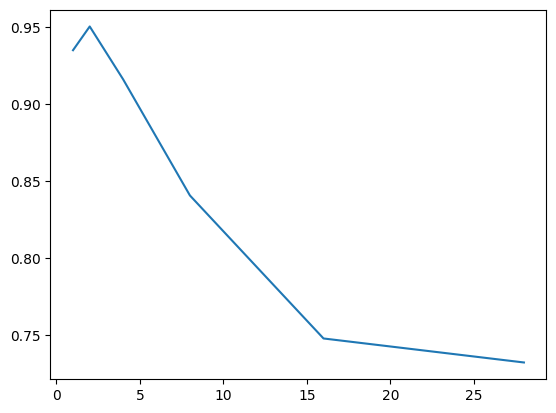

In [108]:
def extract_patches(x, stride=(4, 4), patch_size=(8, 8)):
    """
    Extract overlapping patches using unfold.

    Args:
        x (Tensor): Input tensor of shape (B, C, H, W).
    
    Returns:
        Tensor: Patches of shape (B, num_patches, C, patch_H, patch_W).
    """
    B, C, H, W = x.shape
    patches = F.unfold(x, kernel_size=patch_size, stride=stride)
    num_patches = patches.shape[-1]
    patches = patches.transpose(1, 2).reshape(B, num_patches, C, *patch_size)

    return patches


stds = []

patch_sizes = [1, 2, 4, 8, 16, 28]
for ps in patch_sizes:
    s = max(1, ps//2)
    x_patched = extract_patches(x, stride=(s, s), patch_size=(ps, ps))
    x_patched = x_patched.reshape(-1, *x_patched.shape[2:])

    Fx_patched = torch.abs(torch.fft.fftshift(torch.fft.fft2(x_patched, dim=dims)))
    Fx_patched = Fx_patched * Fx_patched
    Fx_patched = Fx_patched / rms(Fx_patched)
    print(Fx_patched.shape)
    print(Fx_patched.min(), Fx_patched.max(), Fx_patched.mean(), Fx_patched.std(dim=0).mean())

    stds.append(Fx_patched.std(dim=0).mean())

plt.plot(patch_sizes, stds)
plt.show()



tensor(1.) tensor(0.5357)


<Figure size 1200x600 with 0 Axes>

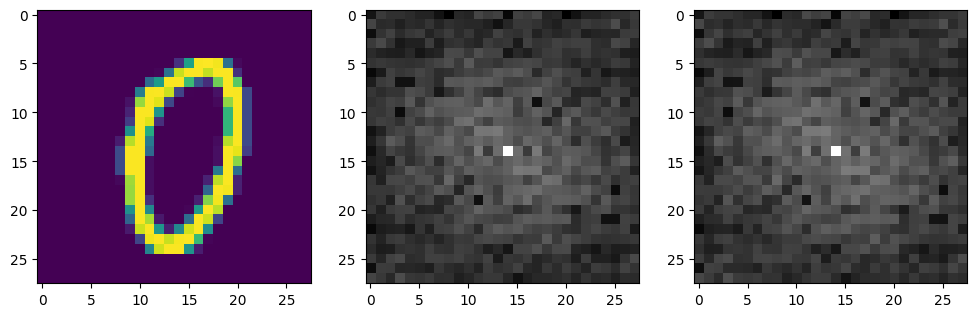

Lambda:  10.0
tensor(1.7721) tensor(1841488.) tensor(2485.5671) tensor(65762.8672)
tensor(1.1577) tensor(1841488.1250) tensor(2485.0740) tensor(65762.8906)


<Figure size 1200x600 with 0 Axes>

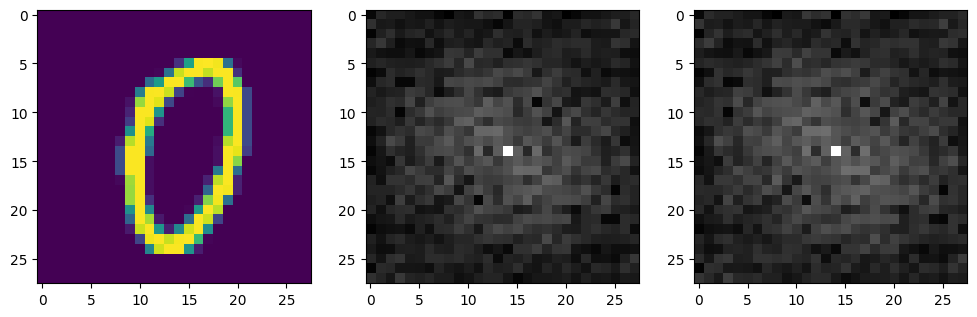

Lambda:  2.0
tensor(1.1544) tensor(368298.4062) tensor(497.9134) tensor(13152.5742)
tensor(0.5009) tensor(368298.5625) tensor(497.4203) tensor(13152.5986)


<Figure size 1200x600 with 0 Axes>

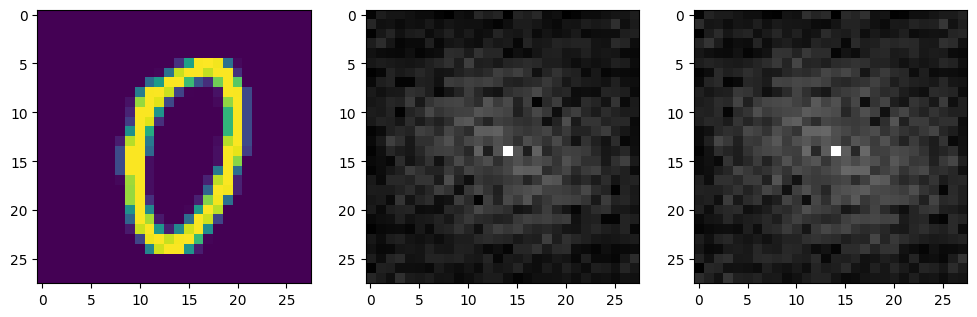

Lambda:  1.0
tensor(1.0772) tensor(184149.7031) tensor(249.4567) tensor(6576.2871)
tensor(0.2960) tensor(184149.8750) tensor(248.9637) tensor(6576.3120)


<Figure size 1200x600 with 0 Axes>

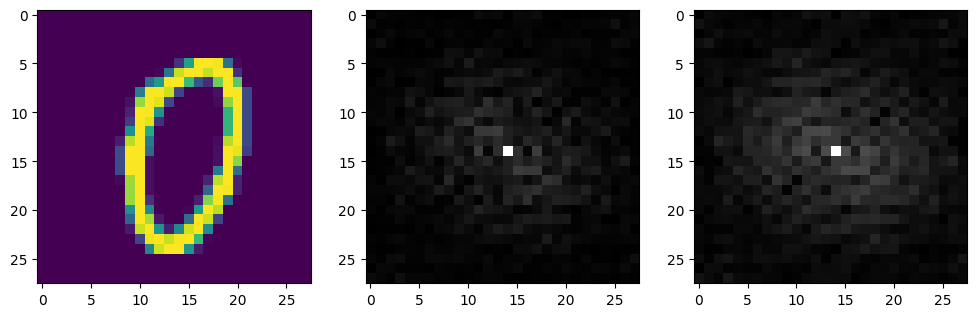

Lambda:  0.1
tensor(1.0077) tensor(18415.8711) tensor(25.8457) tensor(657.6287)
tensor(0.0669) tensor(18416.0410) tensor(25.3526) tensor(657.6545)


<Figure size 1200x600 with 0 Axes>

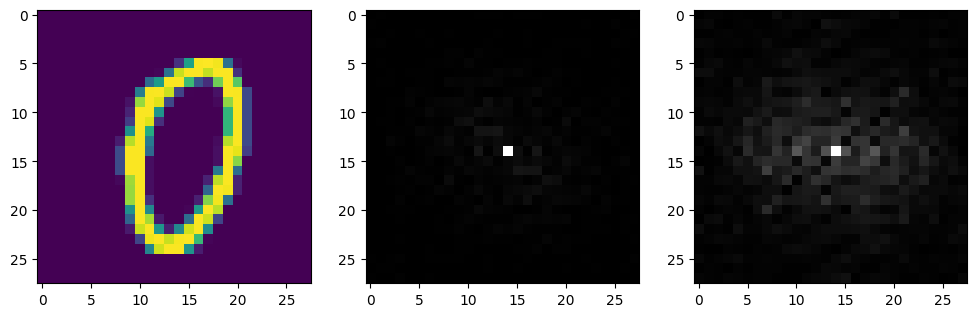

Lambda:  0.01
tensor(1.0008) tensor(1842.4869) tensor(3.4846) tensor(65.7629)
tensor(0.0098) tensor(1842.6561) tensor(2.9915) tensor(65.7964)


<Figure size 1200x600 with 0 Axes>

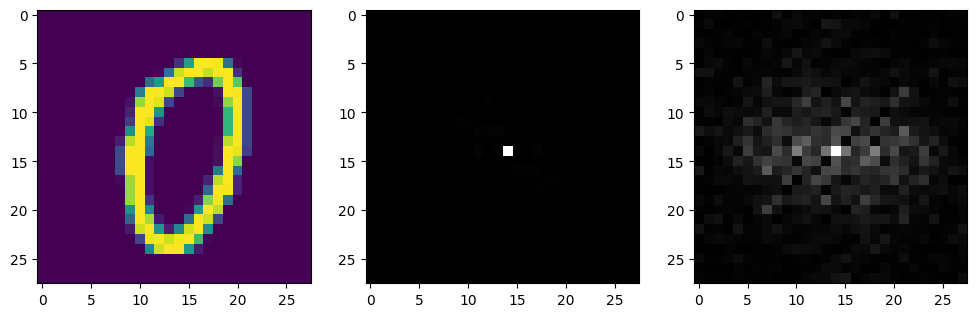

Lambda:  0.001
tensor(1.0001) tensor(185.1487) tensor(1.2485) tensor(6.5763)
tensor(0.0041) tensor(185.3179) tensor(0.7554) tensor(6.6867)


<Figure size 1200x600 with 0 Axes>

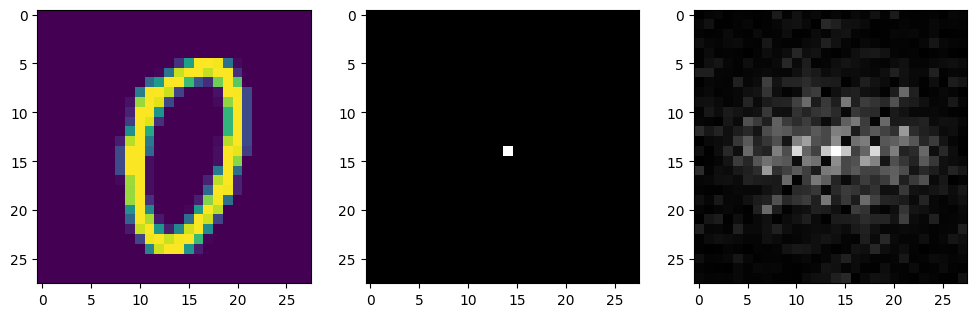

Lambda:  0.0001
tensor(1.0000) tensor(19.4149) tensor(1.0248) tensor(0.6576)
tensor(0.0036) tensor(19.5840) tensor(0.5318) tensor(1.2657)


<Figure size 1200x600 with 0 Axes>

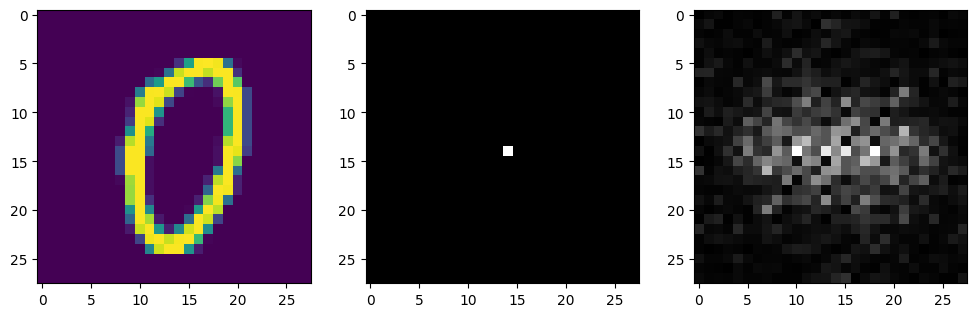

Lambda:  1e-05
tensor(1.0000) tensor(2.8415) tensor(1.0025) tensor(0.0658)
tensor(0.0035) tensor(12.1152) tensor(0.5094) tensor(1.0698)


<Figure size 1200x600 with 0 Axes>

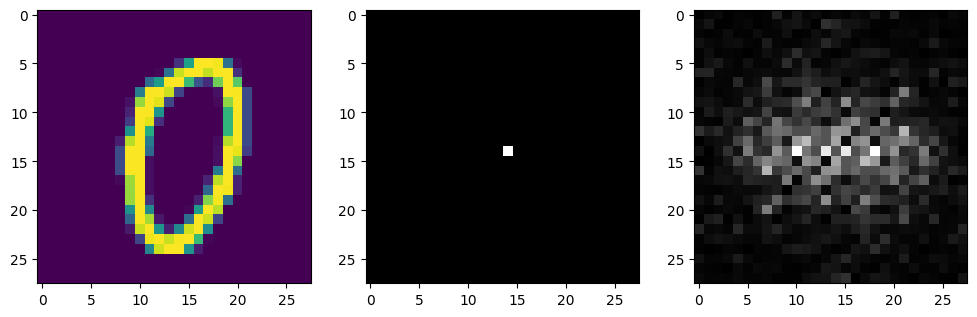

Lambda:  1e-06
tensor(1.0000) tensor(1.1841) tensor(1.0002) tensor(0.0066)
tensor(0.0035) tensor(12.1151) tensor(0.5072) tensor(1.0664)


<Figure size 1200x600 with 0 Axes>

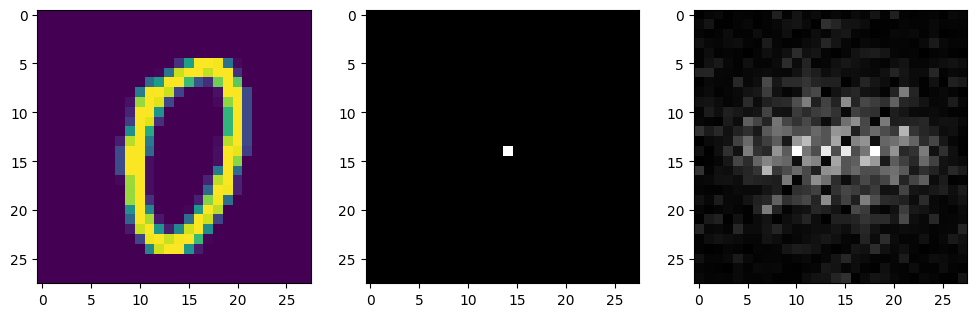

Lambda:  1e-07
tensor(1.) tensor(1.0184) tensor(1.0000) tensor(0.0007)
tensor(0.0035) tensor(12.1151) tensor(0.5070) tensor(1.0662)


<Figure size 1200x600 with 0 Axes>

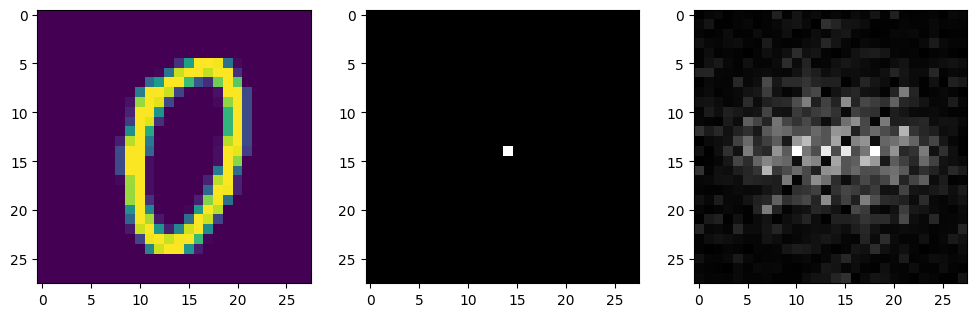

Lambda:  1e-08
tensor(1.) tensor(1.0018) tensor(1.0000) tensor(6.5765e-05)
tensor(0.0035) tensor(12.1151) tensor(0.5070) tensor(1.0662)


<Figure size 1200x600 with 0 Axes>

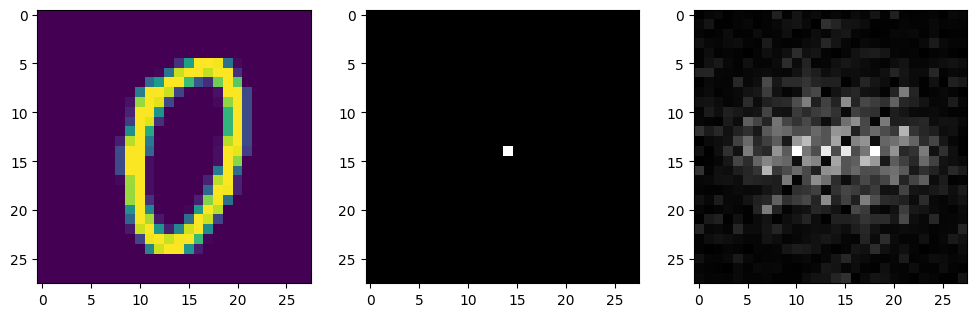

Lambda:  1e-09
tensor(1.) tensor(1.0002) tensor(1.0000) tensor(6.5777e-06)
tensor(0.0035) tensor(12.1151) tensor(0.5070) tensor(1.0662)


<Figure size 1200x600 with 0 Axes>

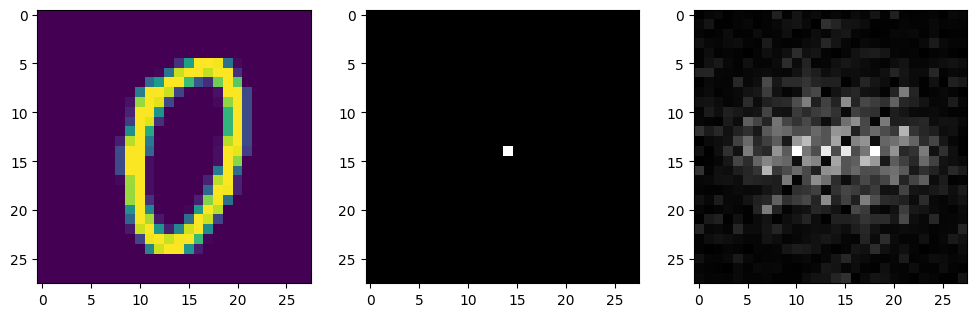

Lambda:  1e-10
tensor(1.) tensor(1.0000) tensor(1.) tensor(6.5607e-07)
tensor(0.0035) tensor(12.1151) tensor(0.5070) tensor(1.0662)


<Figure size 1200x600 with 0 Axes>

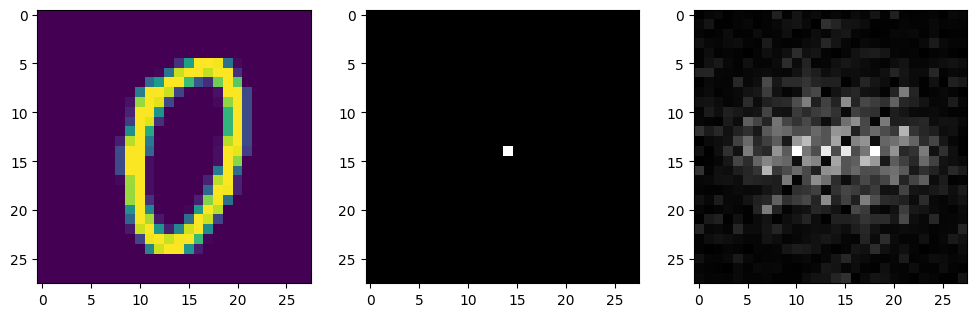

Lambda:  1e-12
tensor(1.) tensor(1.0000) tensor(1.) tensor(8.5204e-09)
tensor(0.0035) tensor(12.1151) tensor(0.5070) tensor(1.0662)


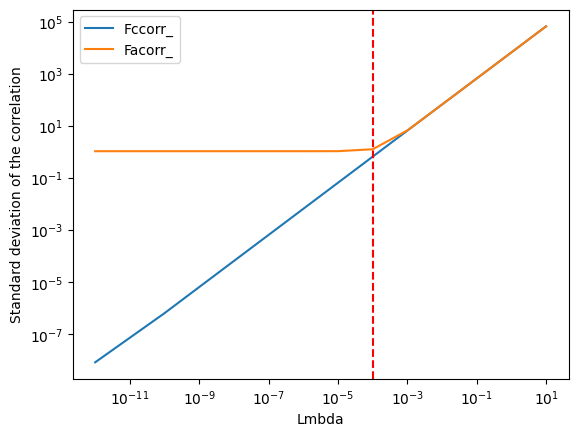

[-24.340312957763672, -23.54984474182129, -22.636754989624023, -14.597347259521484, -5.033998012542725, -2.0569841861724854, -1.6951210498809814, -1.6586494445800781, -1.655376672744751, -1.6551117897033691, -1.6550874710083008, -1.6550852060317993, -1.6550852060317993, -1.6550852060317993]


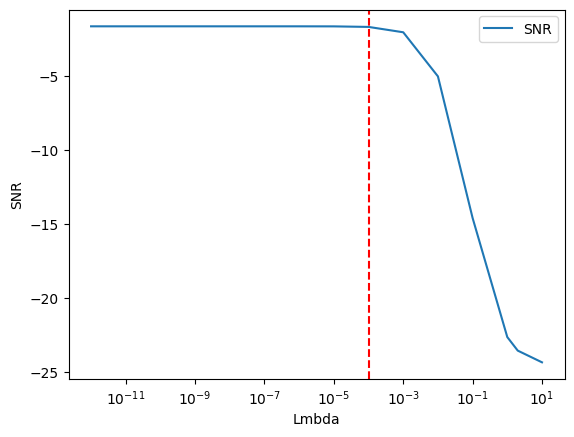

In [111]:
lmbdas = [10., 2., 1., 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-12]

x = train_loader.dataset[1000][0].unsqueeze(0)
y = torch.rand_like(x)

x = x*1300 # saturate mnist images
x = x + 1500.
x = x / 2800.

print(x.min(), x.max())

def standardize(x):
    return x #(x - x.mean()) / x.std()


def compute_snr(signal, noise):
    return 10 * torch.log10(torch.mean(signal**2) / torch.mean(noise**2))

x_ = standardize(x)
y_ = standardize(y)
Fx = torch.abs(torch.fft.fftshift(torch.fft.fft2(x_, dim=dims)))
Fy = torch.abs(torch.fft.fftshift(torch.fft.fft2(y_, dim=dims)))
Facorr = Fx * torch.conj(Fx)
Fccorr = Fx * torch.conj(Fy)

rms_ = rms(torch.abs(Fccorr))

Fccorr = Fccorr / rms_
Facorr = Facorr / rms_

Fccorr_stds = []
Facorr_stds = []
SNR_vals = []

for i, lmbda in enumerate(lmbdas):
    lmbda_scaled = lmbda * rms_
    Fccorr_ = Fccorr + lmbda_scaled
    Facorr_ = Facorr + lmbda_scaled

    # print(x.numpy().shape)
    
    plt.figure(figsize=(12, 6))
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 6))
    axs[0].imshow(x[0].numpy().transpose(1, 2, 0))
    axs[1].imshow(np.log1p(Fccorr_.numpy()[0][0]), cmap='gray')
    axs[2].imshow(np.log1p(Facorr_.numpy()[0][0]), cmap='gray')
    plt.show()

    print("Lambda: ", lmbda)
    print(Fccorr_.min(), Fccorr_.max(), Fccorr_.mean(), Fccorr_.std())
    print(Facorr_.min(), Facorr_.max(), Facorr_.mean(), Facorr_.std())

    Fccorr_stds.append(Fccorr_.std())
    Facorr_stds.append(Facorr_.std())

    Fdconv = Fccorr_ / Facorr_

    # Ideal signal: assume Fdconv ≈ Fx (when Fy ~ x_) or ground truth
    # For simplicity, let’s treat the Wiener deconvolved output as the "signal"
    signal = torch.abs(Fdconv)
    
    # "Noise" is deviation from clean correlation (optional: use clean Fccorr/Facorr)
    noise = signal - torch.abs(Fx)  # Fx is a proxy for true spectrum
    
    snr = compute_snr(signal, noise)
    SNR_vals.append(snr.item())

plt.loglog(lmbdas, Fccorr_stds, label='Fccorr_')
plt.loglog(lmbdas, Facorr_stds, label='Facorr_')
plt.xlabel('Lmbda')
plt.ylabel('Standard deviation of the correlation')
plt.axvline(x=1e-4, color='red', linestyle='--')
plt.legend()
plt.show()


print(SNR_vals)
plt.plot(lmbdas, SNR_vals, label='SNR')
plt.xlabel('Lmbda')
plt.ylabel('SNR')
plt.xscale('log')
plt.axvline(x=1e-4, color='red', linestyle='--')
plt.legend()
plt.show()



In [116]:
# Look at the patches
# Patch size parameters
patch_sizes = [2, 4, 8, 16, 28]

for patch_size in patch_sizes:
    print(f"\nAnalyzing patches of size {patch_size}x{patch_size}")
    
    # Split image into patches
    unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
    patches = unfold(x_)
    patches = patches.reshape(1, x.shape[1], patch_size, patch_size, -1)
    patches = patches.permute(4, 1, 2, 3, 0).squeeze(-1)  # [n_patches, C, H, W]

    # Y
    y_patches = unfold(y_)
    y_patches = y_patches.reshape(1, y.shape[1], patch_size, patch_size, -1)
    y_patches = y_patches.permute(4, 1, 2, 3, 0).squeeze(-1)  # [n_patches, C, H, W]
    
    
    # Initialize stats collectors
    patch_Fccorr_stds = []
    patch_Facorr_stds = []
    patch_SNR_vals = []
    




Analyzing patches of size 2x2

Analyzing patches of size 4x4

Analyzing patches of size 8x8

Analyzing patches of size 16x16

Analyzing patches of size 28x28


In [ ]:
# Look at how SNR vs lambda evolves in training